# 📦 Product & Category Analysis

This notebook implements the fifth dimension of our analytical framework: **Product & Category Analysis**.

**Objective:** Identifying 'Hero' products, optimizing the product catalog, and analyzing brand performance.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')
success_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])].copy()

## 2. Top Performing Products (Hero Products)
Analysis of products by revenue and quantity sold.

Top 10 Hero Products by Revenue:
                                       TotalAmount  Quantity
ProductID ProductName                                       
P00019    LED Desk Lamp                 1740803.34      5697
P00017    Electric Kettle               1714974.27      5527
P00022    Water Bottle                  1714307.52      5659
P00047    Memory Card 128GB             1713710.65      5569
P00031    Kids Toy Car                  1710788.46      5518
P00007    Mechanical Keyboard           1710301.37      5522
P00010    Smartwatch                    1696428.40      5350
P00012    Noise Cancelling Headphones   1692734.69      5431
P00028    Jeans                         1690682.16      5429
P00037    Router                        1690081.08      5625


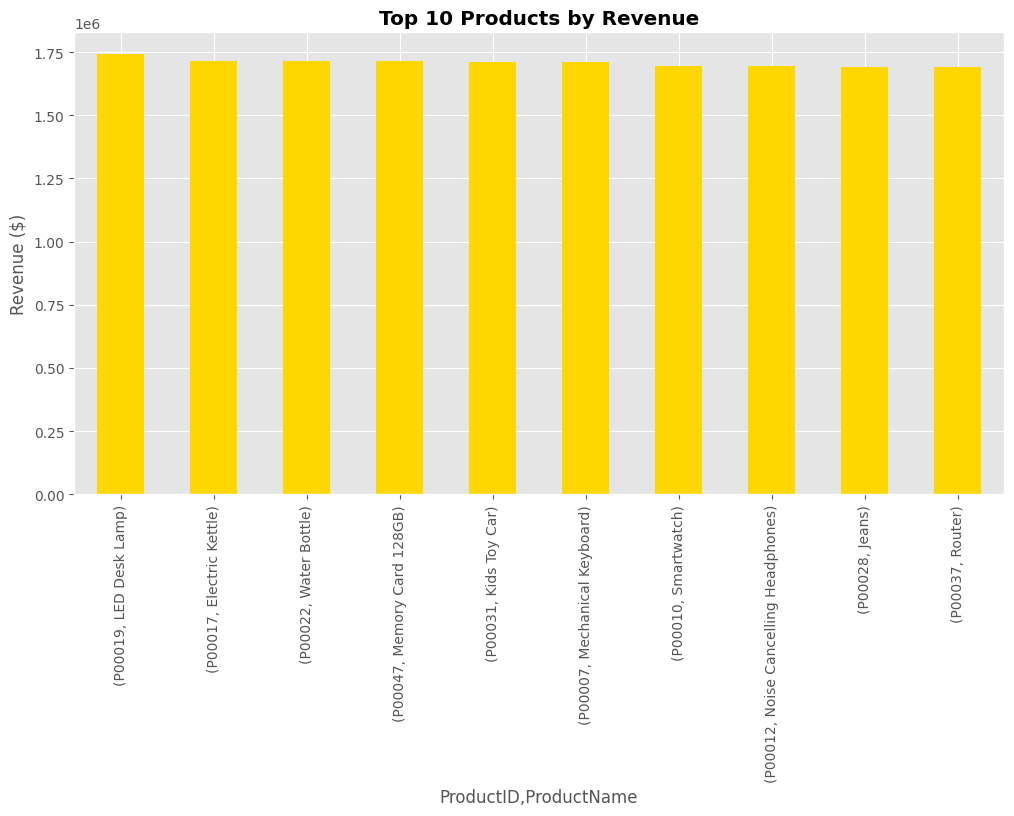

In [2]:
product_stats = success_orders.groupby(['ProductID', 'ProductName']).agg({
    'TotalAmount': 'sum',
    'Quantity': 'sum'
}).sort_values(by='TotalAmount', ascending=False)

print("Top 10 Hero Products by Revenue:")
print(product_stats.head(10))

plt.figure(figsize=(12, 6))
product_stats.head(10)['TotalAmount'].plot(kind='bar', color='gold')
plt.title('Top 10 Products by Revenue', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.show()

## 3. Laggard Products
Products with the lowest sales volume that might need to be discontinued.

Bottom 10 Laggard Products by Revenue:
                            TotalAmount  Quantity
ProductID ProductName                            
P00046    Car Charger        1607469.57      5190
P00011    Fitness Band       1607124.10      5134
P00038    External HDD 2TB   1600468.57      5248
P00029    T-Shirt            1600308.61      5290
P00026    Sunglasses         1592657.68      5181
P00004    USB-C Charger      1580019.12      5226
P00039    Graphic Tablet     1576773.72      5140
P00021    Backpack           1569851.24      5207
P00049    Children's Book    1561675.92      5022
P00035    Desk Plant         1551690.78      5172


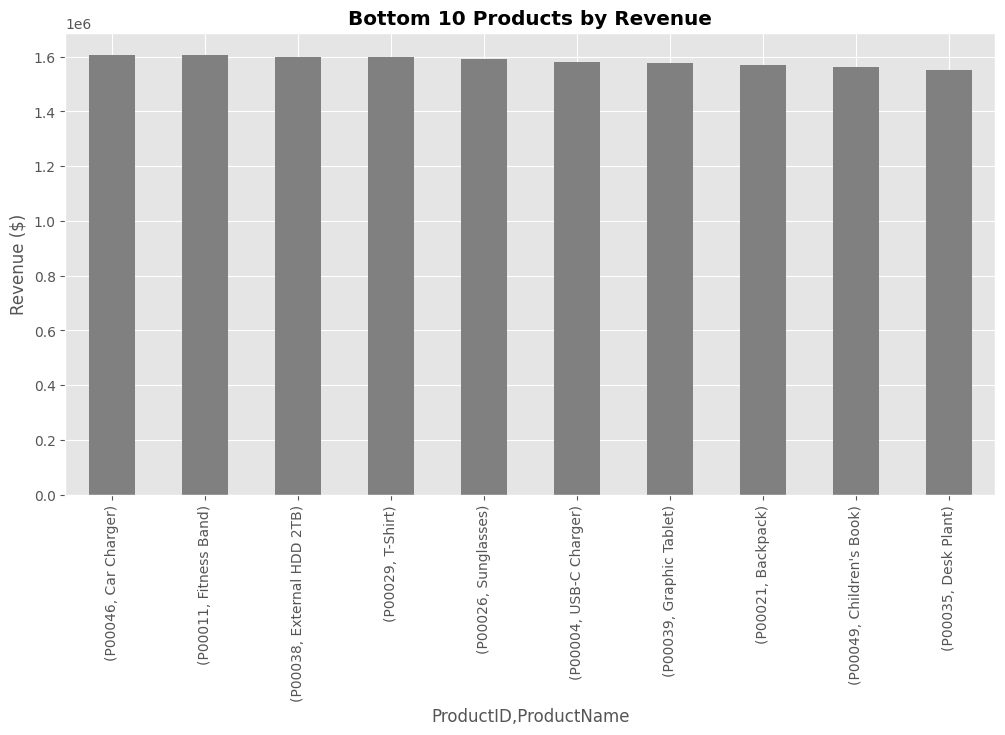

In [3]:
laggards = product_stats.tail(10)
print("Bottom 10 Laggard Products by Revenue:")
print(laggards)

plt.figure(figsize=(12, 6))
laggards['TotalAmount'].plot(kind='bar', color='gray')
plt.title('Bottom 10 Products by Revenue', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.show()

## 4. Brand Performance
Which brands drive the most revenue?

C:\Users\shame\AppData\Local\Temp\ipykernel_25300\3890456857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_revenue.index, y=brand_revenue.values, palette='magma')


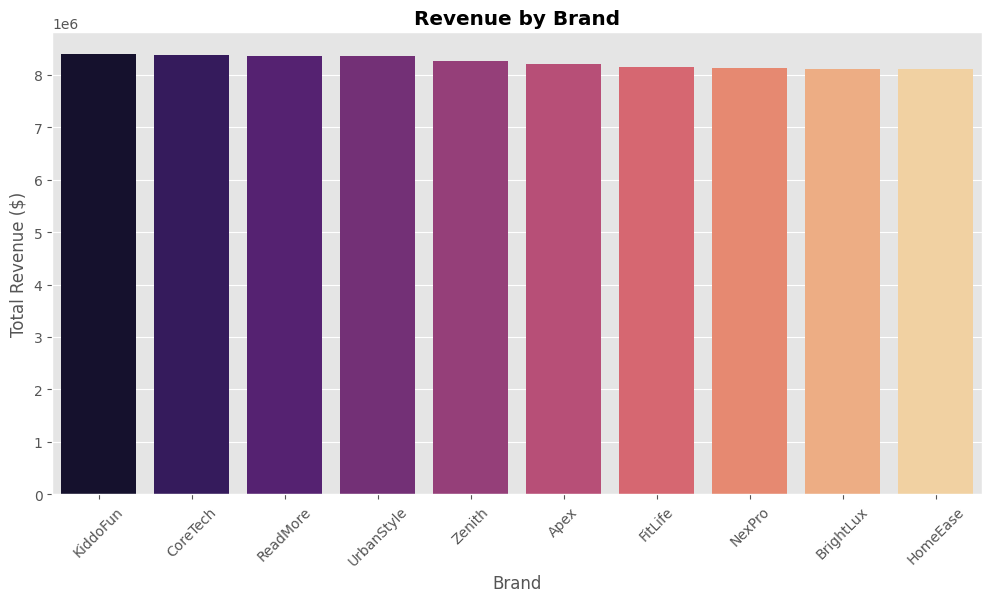

In [4]:
brand_revenue = success_orders.groupby('Brand')['TotalAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=brand_revenue.index, y=brand_revenue.values, palette='magma')
plt.title('Revenue by Brand', fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()